In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import matplotlib.pyplot as plt
import lenstronomy as ls

from lenstronomy.LensModel.lens_model import LensModel
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from seaborn import kdeplot
from pandas import DataFrame as df
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.psf import PSF
from lenstronomy.Data.imaging_data import ImageData
import pickle 
from corner import corner 
import json 

from lensgw import lens_gw as lgw

plt.rcParams.update({'font.family': 'serif'})

In [19]:
posterior = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/best/position_mcmc.pkl'
result = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/best/kwargs_result.json'
sourcemodel = '/home/lauraelina.uronen/Projects/GClocalisation/galaxy-center-localisation/results_final/best/modelplot.pkl'

with open(posterior, 'rb') as f:
    data = pickle.load(f)

with open(result, 'r') as f:    
    kwargs_result = json.load(f)

with open(sourcemodel, 'rb') as f:
    model_plot = pickle.load(f)

source = kwargs_result['kwargs_source']
lens = kwargs_result['kwargs_lens']
lenslight = kwargs_result['kwargs_lens_light']

lens_light_model_list = ['SERSIC_ELLIPSE'] 
source_light_model_list = ['SERSIC_ELLIPSE']
lensLightModel = LightModel(light_model_list=lens_light_model_list)
sourceLightModel = LightModel(light_model_list=source_light_model_list)

z_source = 0.8
z_lens = 0.5
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list, z_source=z_source, z_lens=z_lens)

In [41]:
# build image of the source and lens

numPix = 700
deltaPix = 0.01 

shift = numPix * deltaPix / 2

ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)

fwhm = 0.067 #HST/JWST: 0.067, TMT/ELT: 0.01 in IR
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': deltaPix}
psf = PSF(**kwargs_psf)
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

imageModel = ImageModel(data_class=pixel_grid, 
                        psf_class=psf, 
                        lens_model_class=lensModel, 
                        source_model_class=sourceLightModel, 
                        lens_light_model_class=lensLightModel, 
                        point_source_class=None, 
                        kwargs_numerics=kwargs_numerics)

imageLens = imageModel.image(kwargs_lens=lens,
                              kwargs_source=source,
                                kwargs_lens_light=lenslight,
                                kwargs_ps=None)

imageNoModel = ImageModel(data_class=pixel_grid, 
                        psf_class=psf, 
                        lens_model_class=None, 
                        source_model_class=sourceLightModel, 
                        lens_light_model_class=None, 
                        point_source_class=None, 
                        kwargs_numerics=kwargs_numerics)

imageNoLens = imageNoModel.image(kwargs_lens=None,
                              kwargs_source=source,
                                kwargs_lens_light=None,
                                kwargs_ps=None)

sourceplot = model_plot.source(numPix=numPix, deltaPix=deltaPix)[0]

In [53]:
def coord_to_pix(ra, dec, pixel_grid):
    pix_x, pix_y = pixel_grid.map_coord2pix(ra=ra, dec=dec)
    return pix_x, pix_y

true_ra, true_dec = 0.22, -0.05
true_dict = lgw(true_ra, true_dec, lensModel, lens)
true_imra = true_dict['theta_ra']
true_imdec = true_dict['theta_dec']

numsamp = 50000
pt_ra = data[:numsamp][:,0]
pt_dec = data[:numsamp][:,1]

In [54]:
theta_ra = []
theta_dec = []

from tqdm import tqdm

for i in tqdm(range(len(pt_ra))):
    dicti = lgw(pt_ra[i], pt_dec[i], lensModel, lens)
    for j in range(len(dicti['theta_ra'])):
        theta_ra.append(dicti['theta_ra'][j])
        theta_dec.append(dicti['theta_dec'][j])

100%|██████████| 50000/50000 [18:45<00:00, 44.43it/s]


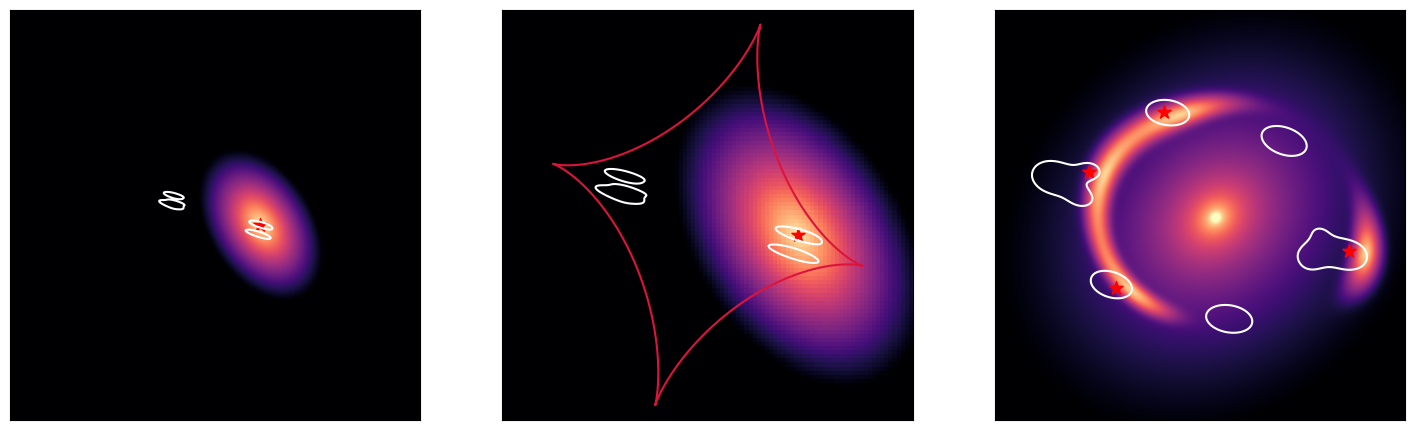

In [74]:
fig, ax = plt.subplots(1, 3, figsize=(18, 10))

im1 = ax[0].imshow(sourceplot, origin='lower', cmap='magma', norm=LogNorm(vmin=1e-6, vmax=0.05),extent=(-shift+true_ra, shift+true_ra, -shift+true_dec, shift+true_dec))
kdeplot(x=pt_ra, y=pt_dec, ax=ax[0], color='white', levels=[1-0.65])
ax[0].scatter(true_ra, true_dec, color='red', marker='*', s=100)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)

im2 = ax[1].imshow(sourceplot, origin='lower', cmap='magma', norm=LogNorm(vmin=1e-6, vmax=0.05),extent=(-shift+true_ra, shift+true_ra, -shift+true_dec, shift+true_dec))
kdeplot(x=pt_ra, y=pt_dec, ax=ax[1], color='white', levels=[1-0.65])
ax[1].scatter(true_ra, true_dec, color='red', marker='*', s=100)
lens_plot.caustics_plot(ax[1], pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=lens, color_caustic='crimson', color_crit='crimson')
ax[1].set_xlim(-0.5,0.5)
ax[1].set_ylim(-0.5,0.5)

im3 = ax[2].imshow(imageLens, origin='lower', cmap='magma', norm=LogNorm(vmin=1e-6, vmax=0.05), extent=(-shift+true_ra, shift+true_ra, -shift+true_dec, shift+true_dec))
kdeplot(x=theta_ra, y=theta_dec, ax=ax[2], color='white', levels=[1-0.65])
ax[2].scatter(true_imra, true_imdec, color='red', marker='*', s=100)
ax[2].set_xlim(-3,3)
ax[2].set_ylim(-3,3)

for a in ax:
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.savefig('final_plot.png', dpi=1000)